In [ ]:

# 1. How has inflation evolved in Nigeria from 2019 to 2025
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import sys


PROJECT_ROOT = Path().resolve().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.config import PROCESSED_DATA_DIR, NG_DARK, NG_GREEN, NG_GOLD
from src.utils.saveFigure import saveFigure
import pandas as pd

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica'],
    'text.color': NG_DARK,
    'axes.labelcolor': NG_DARK,
    'xtick.color': NG_DARK,
    'ytick.color': NG_DARK,
    'axes.edgecolor': '#E0E0E0',
    'grid.color': '#EAEAEA',
    'grid.linestyle': '--',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white'
})
    
    


# load clean csv
df = pd.read_csv(PROCESSED_DATA_DIR / 'inflation_in_nigeria_2019_2025_clean.csv', parse_dates=['date'])
df['year'] = df['date'].dt.year


# 1. How has inflation evolved in Nigeria from 2019 to 2025?
"""
    First i group the data by year, and take the min, max, mean and std of each column, this is to show the lowest and highest points
    of inflation each year, the average inflation rate and the volatility of inflation each year
"""

inflation_range = (
    df.groupby(df['date'].dt.year)['yoy_inflation_pct']
    .agg(['mean', 'min', 'max', 'std']) 
)
# save figure 
fig1 = plt.figure(figsize=(10, 5))

sns.lineplot(
    data=inflation_range,
    x=inflation_range.index,
    y='mean',
    color=NG_GREEN,
    marker='o',
    linewidth=3,
    markersize=8,
    markerfacecolor=NG_GOLD, 
    markeredgecolor=NG_GREEN
)

plt.title("Inflation Trend in Nigeria (2019–2025)")
plt.xlabel("Year")
plt.ylabel("Average Inflation (%)")

saveFigure('inflation_trend_line_plot.png', fig=fig1)

# ____ Plot the volatility by year
plt.clf()
fig2 = plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df,
    x='year',
    y='yoy_inflation_pct',
    color=NG_GOLD,        
    linewidth=1.5,
    fliersize=4              
)


plt.title("Yearly Inflation Volatility & Distribution in Nigeria (2019–2025)", 
          fontsize=14, fontweight='bold', pad=15, loc='left')
plt.xlabel("Year", fontsize=11, labelpad=10)
plt.ylabel("Year on Year Inflation Rate (%)", fontsize=11, labelpad=10)
saveFigure('inflation_trend_box_plot.png', fig=fig2)

# 1. Use df (the original monthly data), filter for 2024, and sort from lowest to highest
outlier_hunter = df[df['date'].dt.year == 2024].sort_values(by='yoy_inflation_pct')


# 2. Print out the date and the inflation values to locate that ~15.5% outlier
print(outlier_hunter[['date', 'yoy_inflation_pct']])



/var/folders/w8/kmbm7vc17vb80lb9kj5f78mw0000gn/T/ipykernel_58164/1713416919.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=overall_change.values, y=overall_change.index, palette="viridis")


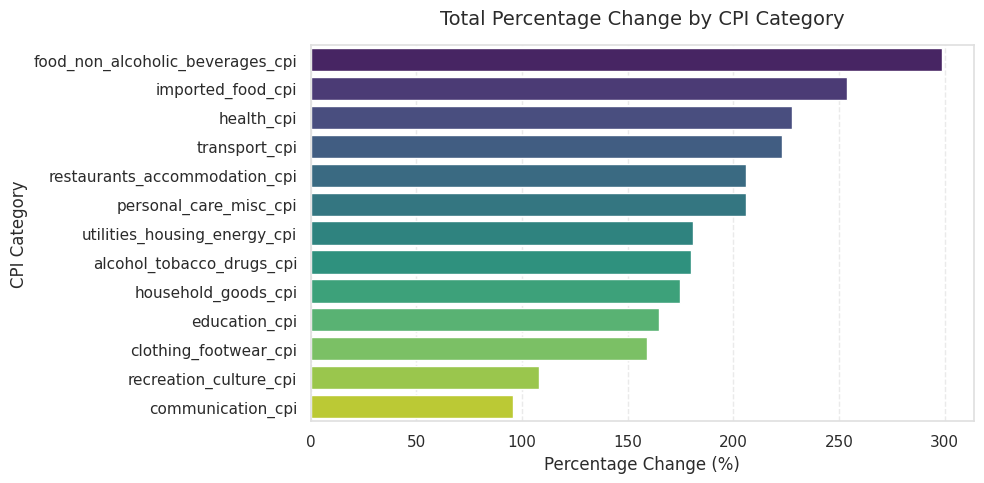

✅ Figure successfully saved to: /Users/pro2020/projects/python/inflation_in_Nigeria/output/figures/total-cpi-change-by-category.png


<Figure size 640x480 with 0 Axes>

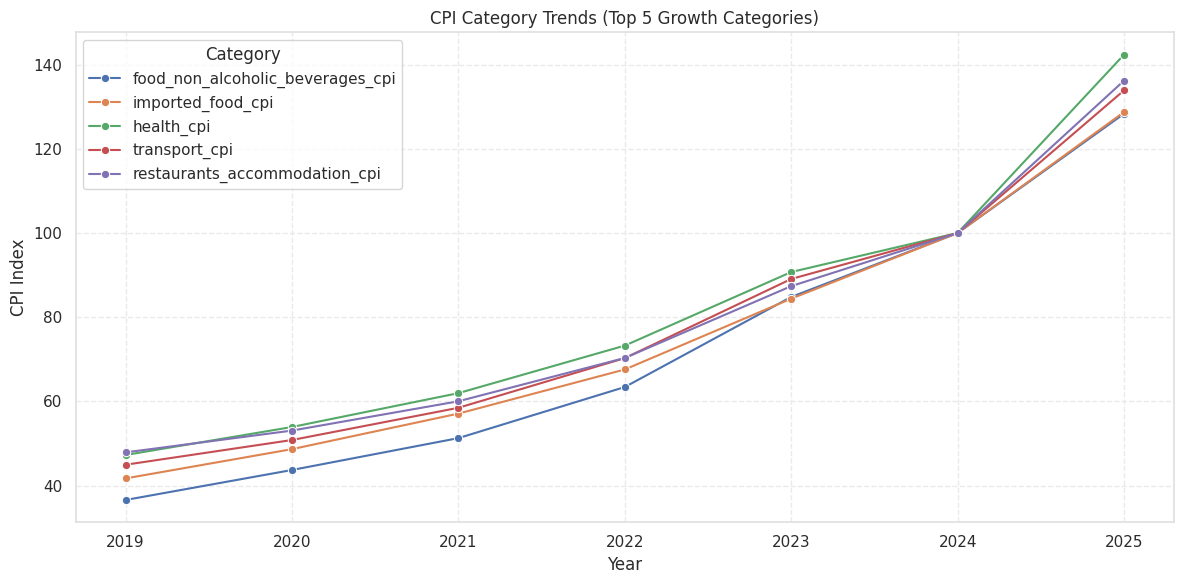

✅ Figure successfully saved to: /Users/pro2020/projects/python/inflation_in_Nigeria/output/figures/top_5_cpi_growth.png


In [3]:
# 2. Which CPI categories experienced the highest inflation growth?
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import pandas as pd

from pathlib import Path
PROJECT_ROOT = Path().resolve().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
    
    
from src.config import PROCESSED_DATA_DIR, NG_DARK, NG_GREEN, NG_GOLD
from src.utils.saveFigure import saveFigure

sns.set_theme(style="whitegrid")
# set sns style
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial', 'Helvetica'],
    'text.color': NG_DARK,
    'axes.labelcolor': NG_DARK,
    'xtick.color': NG_DARK,
    'ytick.color': NG_DARK,
    'axes.edgecolor': '#E0E0E0',
    'grid.color': '#EAEAEA',
    'grid.linestyle': '--',
    'figure.facecolor': 'white',
    'axes.facecolor': 'white'
})

    


# load clean csv
df = pd.read_csv(PROCESSED_DATA_DIR / 'inflation_in_nigeria_2019_2025_clean.csv', parse_dates=['date'])
df['year'] = df['date'].dt.year

# set date as index
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

# -------- A calculate the overall CPI --------
# calculate the pct for each cpi
cpis_mask = (df.columns.str.contains('cpi'))
# select all cpis then drop the overall cpi from the cpi list
cpi_cols = list(df.columns[cpis_mask])
cols_to_remove = {'overall_cpi', 'core_cpi_ex_food', 'core_cpi_ex_food_energy', 'food_cpi'}
cpi_cols = [item for item in cpi_cols if item not in cols_to_remove]

first_row = df[cpi_cols].iloc[0]
last_row = df[cpi_cols].iloc[-1]
overall_change = (((last_row - first_row) / first_row)* 100).round()
overall_change = overall_change.sort_values(ascending=False)

fig1 = plt.figure(figsize=(10, 5))

# Key step: Numeric values to x, text labels to y
sns.barplot(x=overall_change.values, y=overall_change.index, palette="viridis")

# Add clean titles and labels
plt.title("Total Percentage Change by CPI Category", fontsize=14, pad=15)
plt.xlabel("Percentage Change (%)", fontsize=12)
plt.ylabel("CPI Category", fontsize=12)

plt.tight_layout()
plt.show()
saveFigure("total-cpi-change-by-category.png", fig=fig1)
# clear canvas
plt.clf()


# =========================================================
# 6. Yearly Trend for Top 5 Categories
# =========================================================
top_5 = overall_change.head(5).index.tolist()
annual_top5 = df[top_5].resample("YE").last()
annual_top5 = annual_top5.reset_index()
annual_top5["year"] = annual_top5["date"].dt.year


# =========================================================
# 7. Reshape for Plotting
# =========================================================
annual_melted = annual_top5.melt(
    id_vars="year",
    value_vars=top_5,
    var_name="category",
    value_name="cpi_index"
)


# =========================================================
# 8. Plot Trend Over Time
# =========================================================
fig2 = plt.figure(figsize=(12, 6))

sns.lineplot(
    data=annual_melted,
    x="year",
    y="cpi_index",
    hue="category",
    marker="o"
)

plt.title("CPI Category Trends (Top 5 Growth Categories)")
plt.xlabel("Year")
plt.ylabel("CPI Index")
plt.legend(title="Category")

plt.tight_layout()
plt.show()


saveFigure('top_5_cpi_growth.png', fig=fig2)